# B07 · Semantic transfer

**One skill:** change semantic information while preserving a fair evaluation contract.

PROVIDED exposes the actual graph encoder and full 27-fit course loop; TODO holds three live functions; CHECK catches information/selection errors; EXIT needs your interpretation. Default: fresh frozen-encoder inference and27ridge fits, no cloud/GPU. Full paper pretraining and original ConTextTab Table 2 NOT_RUN. This is not a three-model benchmark.

The portable archive contains authenticated real wine tables, cached FastText vectors, selected YAGO tensors, primary-source evidence and canonical code. No checkout or network is needed when dependencies are installed. The supplied solution is author verification, not learner mastery. Live Colab NOT_CHECKED.

## Concept recap
An embedding turns an input into a numeric vector. Semantic transfer uses meaning learned elsewhere. Anonymous headers preserve text values; numeric-only removes them. Training rows fit the head; validation rows select its penalty; test rows only score it. Every allowed target class may be a candidate token, but the query's true class must stay hidden. ConTextTab uses labeled context with frozen parameters; TabSTAR trains adapters; B07's CARTE probe freezes its encoder and fits ridge.

Predict: must meaningful headers help every table? Write your answer before reading author results.


## Model architecture · CARTE

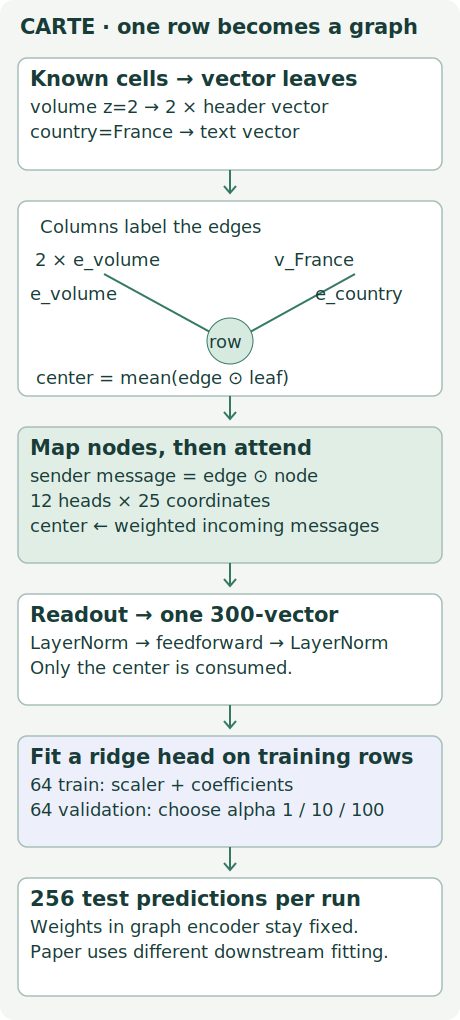

Course CARTE: visible row graph, edge-conditioned messages, frozen selected encoder and fitted ridge head.

## Model architecture · CONTEXTTAB

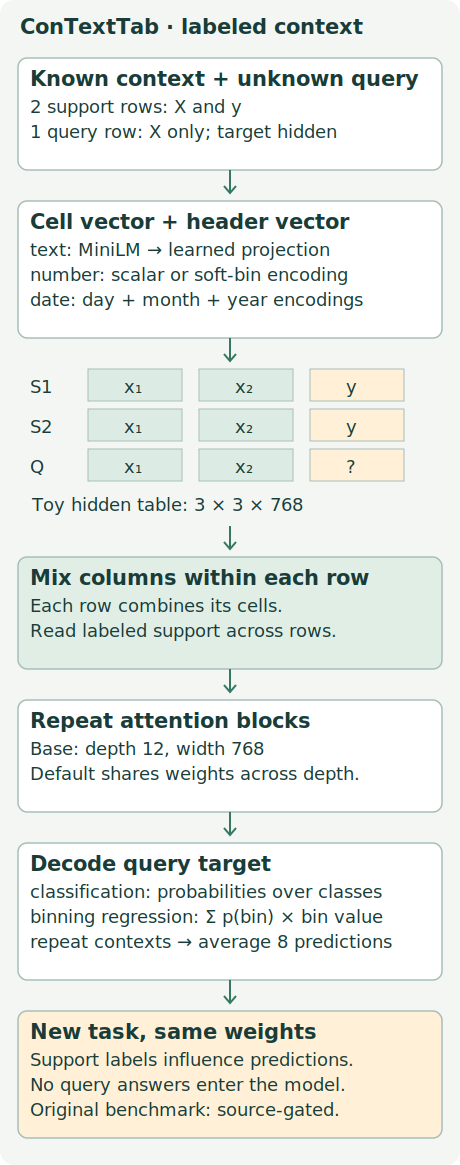

ConTextTab paper concept: labeled support, hidden query target and alternating column/row attention. Original Table 2 run is source-gated.

## Model architecture · TABSTAR

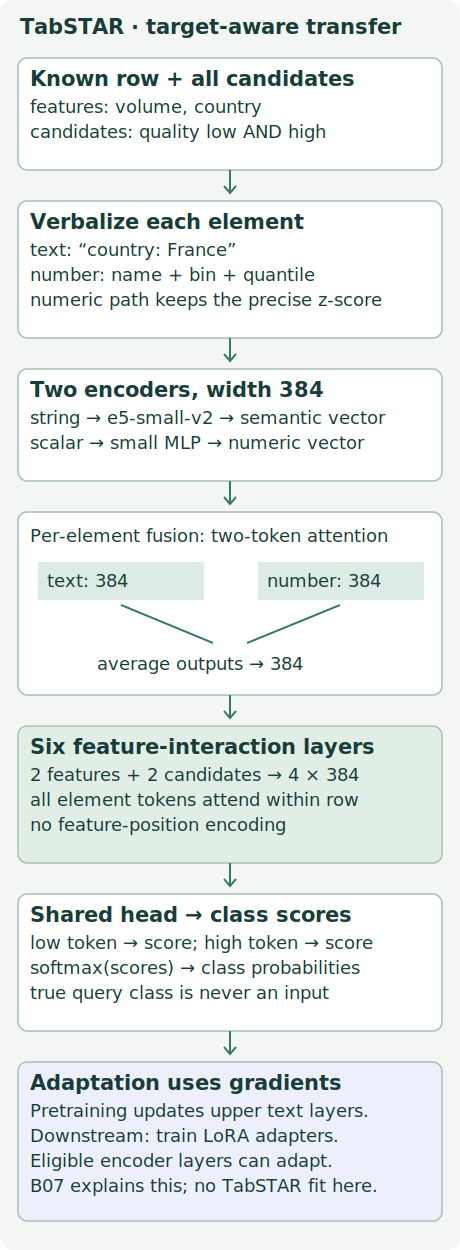

TabSTAR paper architecture: numeric/text pair fusion, target candidates and six within-row interaction layers. No TabSTAR training executed here.

**Trace before coding.** For a standardized volume2 and a France text leaf, illustrative header vectors(1,0),(0,1) give an edge-conditioned center(1,.5). Replacing headers by(.6,.8),(.8,.6) gives(.36,.94) even though cell values stay unchanged. The actual course uses300-dimensional FastText vectors. CARTE's12 heads have25 coordinates each. ConTextTab's toy3×3×768table distinguishes row and column attention. TabSTAR independently fuses each text/numeric pair, then mixes feature and target tokens with six 384-wide layers.

**Experiment contract:**3 real tables,3 split seeds,3 arms;64 train/64 validation/256 test. Targets remain in released transformed units. Alpha candidates1/10/100, choose lowest validation MSE without a validation refit. R²=1−SSE/SST; negative values are possible. For targets[1,3] and predictions[1,2], R²=.5. Removing text can create all-missing rows: retain them as zero 300-vectors.


In [ ]:
# @colab-bootstrap: install only missing packages; warn on version drift.
import importlib.util, importlib.metadata, subprocess, sys, warnings
versions={'numpy': '2.5.0', 'pandas': '3.0.3', 'torch': '2.13.0+cpu', 'scikit-learn': '1.9.0', 'scipy': '1.18.0', 'pyarrow': '24.0.0'}
for module,package in [('numpy','numpy'),('pandas','pandas'),('torch','torch'),('sklearn','scikit-learn'),('scipy','scipy'),('pyarrow','pyarrow')]:
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable,'-m','pip','install',package+'=='+versions[package]])
    elif importlib.metadata.version(package)!=versions[package]:
        warnings.warn(package+' version differs from author protocol; verify numerical tolerances')
import ast,base64,hashlib,io,json,math,statistics,zipfile,tempfile,time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import StandardScaler,PowerTransformer
from sklearn.linear_model import Ridge
from scipy.stats import rankdata,friedmanchisquare,studentized_range
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)


In [ ]:
payload='...'
raw=base64.b64decode(payload)
assert hashlib.sha256(raw).hexdigest()=='db2d4a8e73c869f3381e01b2d6d1260d76032691c7de0a5ec0443676d22d25b5'
workspace=Path(tempfile.mkdtemp(prefix='b07-portable-'))
with zipfile.ZipFile(io.BytesIO(raw)) as bundle: bundle.extractall(workspace)
lab=workspace/'labs'; evidence=lab/'evidence/b07'
print('Portable data/source package authenticated')

## TODO 1 · Remove only the declared information

Implement the3 arms without mutating the input. Use fixed digit labels 6..18,20,0 by original feature slot. Numeric-only must not renumber surviving columns or remove rows.

In [ ]:
def intervene(frame, arm):
    raise NotImplementedError("TODO: intervene")

In [ ]:
def check_intervention(fn):
    frame=pd.DataFrame({'name':['a','b'], 'volume':[2.,3.], 'rating':[4.,5.]},index=[8,2])
    original=frame.copy(deep=True)
    full=fn(frame,'meaningful');anon=fn(frame,'anonymous');numeric=fn(frame,'numeric_only')
    pd.testing.assert_frame_equal(full,original)
    assert list(anon.columns)==['6','7','8'],'Use fixed original feature slots'
    np.testing.assert_array_equal(anon.to_numpy(),frame.to_numpy())
    assert list(numeric.columns)==['7','8'],'Do not renumber retained numeric columns'
    np.testing.assert_array_equal(numeric.to_numpy(),frame[['volume','rating']].to_numpy())
    assert list(numeric.index)==[8,2],'Preserve row identities'
    wide=pd.DataFrame({f'field{i}':[1.] for i in range(15)})
    assert list(fn(wide,'anonymous').columns)==[str(i) for i in range(6,19)]+['20','0'],'Only verified cached digit names'
    pd.testing.assert_frame_equal(frame,original)
    try:fn(frame,'typo')
    except ValueError:pass
    else:raise AssertionError('Unknown intervention accepted')
check_intervention(intervene)
print("Learner contract PASS")

## TODO 2 · Fit and select without test exposure

Fit a StandardScaler and each Ridge candidate on training rows only. Choose minimum validation MSE; return prediction, alpha, mean, scale, coefficient, intercept and all candidate validation_mse values. Reject overlapping identities. Never use test labels.

In [ ]:
def fit_probe(features, target, train, validation, test, alphas=(1.,10.,100.)):
    raise NotImplementedError("TODO: fit_probe")

In [ ]:
def check_selection(fn):
    x=np.array([[0.],[1.],[2.],[3.],[20.],[40.]])
    y=np.array([0.,1.,2.,3.,0.,0.]);tr=np.array([0,1,2]);va=np.array([3]);te=np.array([4,5])
    a=fn(x,y,tr,va,te)
    yy=y.copy();yy[te]=1e10;xx=x.copy();xx[te]*=100
    b=fn(xx,yy,tr,va,te)
    assert a['alpha']==b['alpha']==1.,'Select alpha using validation only'
    np.testing.assert_allclose(a['mean'],[1.]);np.testing.assert_allclose(a['scale'],[np.sqrt(2/3)])
    np.testing.assert_allclose(a['coefficient'],b['coefficient'])
    np.testing.assert_allclose(a['validation_mse'],b['validation_mse'])
    np.testing.assert_allclose(a['prediction'],[15.25,30.25])
    assert len(a['validation_mse'])==3
    try:fn(x,y,tr,np.array([2,3]),te)
    except ValueError:pass
    else:raise AssertionError('Overlapping train/validation accepted')
check_selection(fit_probe)
print("Learner contract PASS")

## TODO 3 · Pair by complete identity

Inputs map(table,seed) to R². Require identical nonempty key sets. Return left-minus-right in sorted key order. Reject missing or different keys.

In [ ]:
def paired_delta(left, right):
    raise NotImplementedError("TODO: paired_delta")

In [ ]:
def check_pairing(fn):
    a={('table',0):.8,('table',1):.6};b={('table',1):.5,('table',0):.6}
    np.testing.assert_allclose(fn(a,b),[.2,.1],atol=1e-14)
    for left,right in [(a,{('table',0):.6}),({},{}),(a,{('table',0):.6,('wrong',1):.5})]:
        try:fn(left,right)
        except ValueError:pass
        else:raise AssertionError('Missing or different identities accepted')
check_pairing(paired_delta)
print("Learner contract PASS")

## PROVIDED · Row graph and receiver-normalized attention

Read the graph indices: row0 receives; row1 supplies. Edge-conditioned messages retain column meaning. Softmax normalizes independently per receiving node.

In [ ]:
def make_graph(row, vectors):
    """A source-oriented star: index[0] receives, index[1] supplies each message."""
    leaves,edges=[],[]
    for column,value in row.items():
        if pd.isna(value):continue
        edge=np.asarray(vectors[column],dtype=np.float32)
        node=np.asarray(vectors[str(value).lower()],dtype=np.float32) if isinstance(value,str) else float(value)*edge
        leaves.append(node);edges.append(edge)
    if not leaves:raise ValueError('All-missing row: no observed leaf; choose an explicit fallback')
    leaves=torch.tensor(np.stack(leaves));edges=torch.tensor(np.stack(edges))
    center=(leaves*edges).mean(0,keepdim=True)
    x=torch.cat([center,leaves]);n=len(leaves);ids=torch.arange(1,n+1)
    index=torch.stack([torch.cat([torch.zeros(n,dtype=torch.long),ids]),torch.cat([ids,ids])])
    attrs=torch.cat([edges,torch.ones_like(edges)])
    return x,index,attrs

def grouped_attention(edge_index, query, key, value):
    """Normalize over incoming messages separately for each receiving node."""
    receiver=edge_index[0]
    logits=(query[receiver]*key).sum(-1)/math.sqrt(query.shape[-1])
    maxima=torch.full((len(query),),-torch.inf,dtype=query.dtype,device=query.device)
    maxima=maxima.scatter_reduce(0,receiver,logits,reduce='amax',include_self=True)
    weights=(logits-maxima[receiver]).exp()
    totals=torch.zeros_like(maxima).index_add(0,receiver,weights)
    weights=weights/totals[receiver]
    output=torch.zeros_like(query).index_add(0,receiver,weights[:,None]*value)
    return output,weights

## PROVIDED · Actual transferred model

These definitions exactly match the inherited L074 selected architecture. Follow all300 coordinates through initial maps,12attention heads and the center readout. There is no hidden API model.

In [ ]:
class Attention(nn.Module):
    def __init__(self,d=300,heads=12):
        super().__init__();self.heads=heads
        self.lin_query=nn.Linear(d,d,bias=False)
        self.lin_key=nn.Linear(d,d,bias=False)
        self.lin_value=nn.Linear(d,d,bias=False)
    def forward(self,x,index,edge):
        z=edge*x[index[1]]
        q,k,v=self.lin_query(x),self.lin_key(z),self.lin_value(z)
        width=q.shape[1]//self.heads
        return torch.cat([grouped_attention(index,q[:,i:i+width],k[:,i:i+width],v[:,i:i+width])[0] for i in range(0,q.shape[1],width)],1)

class Readout(nn.Module):
    def __init__(self):
        super().__init__();self.g_attn=Attention()
        self.linear_net_x=nn.Sequential(nn.Linear(300,300),nn.Dropout(0),nn.GELU(),nn.Linear(300,300))
        self.norm1_x=nn.LayerNorm(300);self.norm2_x=nn.LayerNorm(300)
    def forward(self,x,index,edge):
        # The pinned code has no node residual addition in this block.
        x=self.norm1_x(self.g_attn(x,index,edge))
        return self.norm2_x(self.linear_net_x(x))

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.initial_x=nn.Sequential(nn.Linear(300,300),nn.GELU(),nn.LayerNorm(300))
        self.initial_e=nn.Sequential(nn.Linear(300,300),nn.GELU(),nn.LayerNorm(300))
        self.read_out_block=Readout()
    def forward(self,x,index,edge):
        return self.read_out_block(self.initial_x(x),index,self.initial_e(edge))
    def rows(self,x,index,edge,heads):
        # Only center outputs are consumed. Leaf inputs still supply keys/values.
        receiver_map=torch.full((len(x),),-1,dtype=torch.long)
        receiver_map[heads]=torch.arange(len(heads))
        keep=receiver_map[index[0]]>=0
        row_ids=receiver_map[index[0,keep]]
        x=self.initial_x(x);edge=self.initial_e(edge[keep])
        attn=self.read_out_block.g_attn
        z=edge*x[index[1,keep]]
        q,k,v=attn.lin_query(x[heads]),attn.lin_key(z),attn.lin_value(z)
        row_index=torch.stack([row_ids,torch.zeros_like(row_ids)])
        width=q.shape[1]//attn.heads
        output=torch.cat([grouped_attention(row_index,q[:,i:i+width],k[:,i:i+width],v[:,i:i+width])[0] for i in range(0,q.shape[1],width)],1)
        output=self.read_out_block.norm1_x(output)
        return self.read_out_block.norm2_x(self.read_out_block.linear_net_x(output))

## PROVIDED · Weight transfer, batches and preprocessing

Strictly load every selected tensor. The parent checkpoint was authenticated before extraction. Fit numeric transforms on train only; preserve missing values and omit wholly unobserved training columns.

In [ ]:
def load_encoder(checkpoint,pretrained,seed):
    torch.manual_seed(seed);model=Encoder()
    if pretrained:
        state=torch.load(checkpoint,map_location='cpu',weights_only=True)
        selected={k:state['ft_base.'+k] for k in model.state_dict()}
        model.load_state_dict(selected,strict=True)
    return model

def batch_graphs(graphs):
    xs,es,attrs,heads=[],[],[],[];offset=0
    for x,index,edge in graphs:
        heads.append(offset);xs.append(x);es.append(index+offset);attrs.append(edge);offset+=len(x)
    return torch.cat(xs),torch.cat(es,1),torch.cat(attrs),torch.tensor(heads)

def embed(model,graphs):
    model.eval();parts=[]
    with torch.no_grad():
        for i in range(0,len(graphs),64):
            x,index,edge,heads=batch_graphs(graphs[i:i+64]);parts.append(model.rows(x,index,edge,heads).numpy())
    return np.concatenate(parts)

def normalize_numeric(frame,train):
    """Fit per-column maps using train only; constant columns need no power fit."""
    out=frame.copy();policy={}
    for col in frame.select_dtypes(include='number'):
        observed=frame.iloc[train][col].dropna()
        if len(observed)==0:
            out[col]=np.nan;policy[col]='unobserved_train_omit';continue
        constant=observed.nunique()==1
        transformer=StandardScaler() if constant else PowerTransformer()
        transformer.fit(frame.iloc[train][[col]])
        out[col]=transformer.transform(frame[[col]]).flatten()
        policy[col]='standard_constant' if constant else 'power'
    return out,policy

## PROVIDED · Empty rows preserve the evaluation population

Text removal may leave no observed leaves. Return a declared zero 300-vector for that row. Do not silently drop hard queries.

In [ ]:
def encode_table(model,frame,vectors,graph_fn,embed_fn):
    """Preserve all rows; no observed leaf maps to a declared zero representation."""
    records=frame.to_dict('records')
    observed=[i for i,row in enumerate(records) if any(not pd.isna(v) for v in row.values())]
    out=np.zeros((len(frame),300),dtype=np.float32)
    if observed:
        graphs=[graph_fn(records[i],vectors) for i in observed]
        out[observed]=embed_fn(model,graphs)
    return out

## PROVIDED · Complete fresh27-fit loop

The function below accepts your live intervention and head functions. It never reads test labels to fit/select. Saved coefficients, embeddings and predictions make independent reconstruction possible.

In [ ]:
def run_course(lab,output,intervention=intervene,probe=fit_probe):
    lab=Path(lab);output=Path(output);output.mkdir(parents=True,exist_ok=True)
    config_path=lab/'evidence/b07/course-protocol.json';cfg=json.loads(config_path.read_text())
    for name,digest in {**cfg['portable_inputs'],**cfg['implementation_hashes']}.items():
        if hashlib.sha256((lab/name).read_bytes()).hexdigest()!=digest:
            raise ValueError('Input authentication failed: '+name)
    torch.set_num_threads(1);torch.use_deterministic_algorithms(True)
    root=lab/'data/b07';meta=json.loads((root/'manifest.json').read_text())
    v=np.load(root/'vectors.npz',allow_pickle=False);vectors=dict(zip(v['names'].tolist(),v['vectors']))
    model=load_encoder(root/'selected_checkpoint.pt',True,0).eval()
    for parameter in model.parameters():parameter.requires_grad_(False)
    weights_before={k:v.clone() for k,v in model.state_dict().items()}
    records=[];splits=[];started=time.monotonic()
    for dataset in cfg['datasets']:
        frame=pd.read_parquet(root/(dataset+'.parquet'));target=meta['datasets'][dataset]['target'];y=frame.pop(target).to_numpy(dtype=float)
        if len(frame)!=384:raise ValueError('Original sample size changed')
        for seed in cfg['seeds']:
            ids=np.random.default_rng(seed+74).permutation(384);tr,va,te=ids[:64],ids[64:128],ids[128:]
            normalized,policy=normalize_numeric(frame,tr)
            splits.append(dict(dataset=dataset,seed=seed,train=tr.tolist(),validation=va.tolist(),test=te.tolist(),numeric_policy=policy))
            for arm in cfg['arms']:
                x=intervention(normalized,arm)
                features=encode_table(model,x,vectors,make_graph,embed)
                if not np.isfinite(features).all():raise ValueError('Nonfinite features')
                head=probe(features,y,tr,va,te,alphas=cfg['head']['alphas'])
                run_id=f'{dataset}-{seed}-{arm}'
                np.savez_compressed(output/(run_id+'.npz'),features=features)
                feature_hash=hashlib.sha256((output/(run_id+'.npz')).read_bytes()).hexdigest()
                records.append(dict(dataset=dataset,seed=seed,arm=arm,columns=list(x.columns),test_ids=te.tolist(),source_ids=[meta['datasets'][dataset]['source_rows'][i] for i in te],target=y[te].tolist(),head=head,feature_file=run_id+'.npz',feature_sha256=feature_hash,features_sha256=hashlib.sha256(features.tobytes()).hexdigest()))
            print(dataset,'seed',seed,'three arms complete',flush=True)
    for key,value in model.state_dict().items():
        if not torch.equal(value,weights_before[key]):raise ValueError('Frozen encoder changed')
    report=dict(name=cfg['name'],protocol_sha256=hashlib.sha256(config_path.read_bytes()).hexdigest(),splits=splits,records=records,encoder_updated=False)
    (output/'results.json').write_text(json.dumps(report,indent=2)+'\n')
    (output/'timing.json').write_text(json.dumps(dict(seconds=time.monotonic()-started,course_fits=len(records)),indent=2)+'\n')
    return report

## RUN · Freeze your prediction, then train

Record which table you expect to benefit from names. This cell regenerates all 27 fits locally. Repeating it is a repeatability check, not new independent seeds.

In [ ]:
calls={'intervention':0,'probe':0}
def counted_intervention(*args,**kwargs):
    calls['intervention']+=1
    return intervene(*args,**kwargs)
def counted_probe(*args,**kwargs):
    calls['probe']+=1
    return fit_probe(*args,**kwargs)
fresh=workspace/'fresh-runs'
result=run_course(lab,fresh,intervention=counted_intervention,probe=counted_probe)
assert calls=={'intervention':27,'probe':27}
print('All27 fits used your live functions')

## PROVIDED · Independent audit and source gate

The auditor uses scalar scoring and an independently solved dual ridge system. It rejects wrong keys, labels, selected alpha and missing runs. It does not import the fitted predictor. The source preflight separately authenticates original ConTextTab evidence.

In [ ]:
def audit_course(lab,runs,report=None):
    lab=Path(lab);runs=Path(runs);protocol=lab/'evidence/b07/course-protocol.json';cfg=json.loads(protocol.read_text())
    for name,digest in {**cfg['portable_inputs'],**cfg['implementation_hashes']}.items():
        if hashlib.sha256((lab/name).read_bytes()).hexdigest()!=digest:raise ValueError('Input authentication failed: '+name)
    report=json.loads((runs/'results.json').read_text()) if report is None else report
    if report['protocol_sha256']!=hashlib.sha256(protocol.read_bytes()).hexdigest():raise ValueError('Protocol mismatch')
    if report['encoder_updated'] is not False:raise ValueError('Unexpected encoder update')
    expected={(d,s,a) for d in cfg['datasets'] for s in cfg['seeds'] for a in cfg['arms']}
    keys=[(r['dataset'],r['seed'],r['arm']) for r in report['records']]
    if len(keys)!=len(set(keys)) or set(keys)!=expected:raise ValueError('Incomplete or duplicate run identities')
    splitkeys=[(r['dataset'],r['seed']) for r in report['splits']]
    if len(splitkeys)!=9 or set(splitkeys)!={(d,s) for d,s,a in expected}:raise ValueError('Split coverage')
    splits={(r['dataset'],r['seed']):r for r in report['splits']}
    meta=json.loads((lab/'data/b07/manifest.json').read_text());rows=[];allpred=0
    for r in report['records']:
        d,s,a=r['dataset'],r['seed'],r['arm'];split=splits[d,s]
        ids=np.random.default_rng(s+74).permutation(384);tr,va,te=ids[:64],ids[64:128],ids[128:]
        for name,ix in [('train',tr),('validation',va),('test',te)]:
            if split[name]!=ix.tolist():raise ValueError('Split identity mismatch')
        if r['test_ids']!=te.tolist():raise ValueError('Query identity mismatch')
        source=[meta['datasets'][d]['source_rows'][int(i)] for i in te]
        if r['source_ids']!=source or len(set(source))!=256:raise ValueError('Original source identity mismatch')
        data=pd.read_parquet(lab/'data/b07'/f'{d}.parquet');target=meta['datasets'][d]['target'];y=data.pop(target).to_numpy(dtype=float)
        if not np.array_equal(np.array(r['target']),y[te]):raise ValueError('Label identity mismatch')
        labels=[str(i) for i in range(6,19)]+['20','0'];mapping=dict(zip(data.columns,labels))
        expectedcols=list(data.columns) if a=='meaningful' else [mapping[c] for c in (data.select_dtypes(include='number').columns if a=='numeric_only' else data.columns)]
        if r['columns']!=expectedcols:raise ValueError('Intervention schema mismatch')
        path=runs/r['feature_file']
        if path.parent.resolve()!=runs.resolve():raise ValueError('Feature path escapes run directory')
        if hashlib.sha256(path.read_bytes()).hexdigest()!=r['feature_sha256']:raise ValueError('Feature artifact mismatch')
        x=np.load(path,allow_pickle=False)['features']
        if x.shape!=(384,300) or hashlib.sha256(x.tobytes()).hexdigest()!=r['features_sha256']:raise ValueError('Feature content mismatch')
        h=r['head'];mu=x[tr].astype(float).mean(0);scale=x[tr].astype(float).std(0);scale[scale==0]=1
        np.testing.assert_allclose(h['mean'],mu,rtol=1e-12,atol=1e-12)
        np.testing.assert_allclose(h['scale'],scale,rtol=1e-12,atol=1e-12)
        z=(x.astype(float)-mu)/scale;zt=z[tr]-z[tr].mean(0);yt=y[tr]-y[tr].mean()
        losses=[];betas=[];biases=[]
        # Solve the dual ridge system independently of sklearn's fitted object.
        for alpha in cfg['head']['alphas']:
            beta=zt.T@np.linalg.solve(zt@zt.T+alpha*np.eye(64),yt)
            intercept=float(y[tr].mean()-z[tr].mean(0)@beta)
            losses.append(float(np.mean((z[va]@beta+intercept-y[va])**2)));betas.append(beta);biases.append(intercept)
        best=min(range(3),key=lambda i:losses[i])
        if h['alpha']!=cfg['head']['alphas'][best]:raise ValueError('Invalid validation selection')
        np.testing.assert_allclose(h['validation_mse'],losses,rtol=2e-8,atol=1e-9)
        np.testing.assert_allclose(h['coefficient'],betas[best],rtol=2e-7,atol=1e-8)
        np.testing.assert_allclose(h['intercept'],biases[best],rtol=1e-8,atol=1e-9)
        pred=np.asarray(h['prediction'],dtype=float)
        if pred.shape!=(256,) or not np.isfinite(pred).all():raise ValueError('Prediction coverage or nonfinite values')
        np.testing.assert_allclose(pred,z[te]@betas[best]+biases[best],rtol=2e-8,atol=1e-8)
        yy=r['target'];mean=math.fsum(yy)/len(yy)
        sse=math.fsum((float(v)-float(t))**2 for v,t in zip(pred,yy));sst=math.fsum((float(t)-mean)**2 for t in yy)
        rows.append(dict(dataset=d,seed=s,arm=a,r2=1-sse/sst,rmse=math.sqrt(sse/256),selected_alpha=h['alpha']))
        allpred+=len(pred)
    aggregate=[];paired=[];ranks=[]
    bykey={(r['dataset'],r['seed'],r['arm']):r for r in rows}
    for d in cfg['datasets']:
        means=[]
        for a in cfg['arms']:
            values=[bykey[d,s,a]['r2'] for s in cfg['seeds']];means.append(statistics.mean(values))
            aggregate.append(dict(dataset=d,arm=a,r2_mean=statistics.mean(values),r2_sd=statistics.stdev(values)))
        ranks.append(rankdata(-np.array(means)).tolist())
        for left,right in [('anonymous','meaningful'),('numeric_only','anonymous')]:
            values=[bykey[d,s,left]['r2']-bykey[d,s,right]['r2'] for s in cfg['seeds']]
            paired.append(dict(dataset=d,contrast=left+' minus '+right,seed_deltas=values,mean=statistics.mean(values),sd=statistics.stdev(values)))
    statistic,pvalue=friedmanchisquare(*np.array(ranks).T)
    return dict(status='COMPLETE_COURSE_EXPERIMENT',fits=len(rows),test_predictions=allpred,rows=rows,aggregate=aggregate,paired=paired,exploratory_ranks=dict(arms=cfg['arms'],mean=np.mean(ranks,axis=0).tolist(),friedman_p=float(pvalue),nemenyi_cd=float(studentized_range.ppf(.95,3,np.inf)/np.sqrt(2)*np.sqrt(3*4/(6*3))),warning='Only three related wine tables; these are descriptive checks, not independent-domain significance evidence.'),head_reconstruction='Independent dual ridge solution PASS',pretraining='NOT_RUN',paper_result='INCOMPLETE_SOURCE_PROTOCOL',learner='PENDING_WRITTEN_DEFENSE')

def audit_sources(source):
    source=Path(source);inventory=json.loads((source/'inventory.json').read_text())
    good=[r for r in inventory if r['status']=='OK']
    for r in good:
        if hashlib.sha256((source/r['file']).read_bytes()).hexdigest()!=r['sha256']:
            raise ValueError('Source artifact mismatch: '+r['file'])
    old=(source/'original/contexttab/contexttab.py').read_text();new=(source/'github/sap_rpt_oss/rpt.py').read_text()
    assert 'replace=True' in old and 'replace=False' in new
    tree=json.loads((source/'original-tree.json').read_text());files=[x['path'] for x in tree['tree'] if x['type']=='blob']
    hf=json.loads((source/'hf-model.json').read_text());hf_files=[x['rfilename'] for x in hf['siblings']]
    return dict(name='B07-CONTEXTTAB-BAGGING',status='INCOMPLETE_SOURCE_PROTOCOL',paper='arXiv:2506.10707v1 Table2, binning base versus without bagging, CARTE subset',published_targets=dict(base_accuracy_percent=76.,base_r2_percent=71.4,without_bagging_accuracy_delta_pp=-.4,without_bagging_r2_delta_pp=-.4),original_git_revision=json.loads((source/'original-commits.json').read_text())[0]['sha'],current_git_revision=json.loads((source/'github-head.json').read_text())['sha'],hf_revision=hf['sha'],hf_files=hf_files,archived_files=len(good),unavailable_requests=[dict(file=r['file'],error=r['error']) for r in inventory if r['status']!='OK'],documented_conflicts=['Original June code uses replacement in bagging; current code uses replace=False despite its replacement comment.','Original default checkpoint l2/base.pt is a direct-regression default, not authenticated as Table2 binning base.','Current wrapper defaults to a November2025 checkpoint, later than the June2025 paper.'],missing=['Authenticated Table2 binning-base checkpoint and its original configuration','Exact complete CARTE membership with original train/validation/test row identities','Benchmark evaluator including preprocessing, context/seed/bagging settings and aggregation'],source_tree_scope=files,run_dispatch='REFUSED_BEFORE_COMPUTE',fresh_paper_inference='NOT_RUN',full_pretraining='NOT_RUN',full_benchmark='NOT_RUN',paid_usd=0,release_alias='Current model card documents ConTextTab -> SAP-RPT-1-OSS; alias alone does not authenticate Table2 protocol')

In [ ]:
course=audit_course(lab,fresh)
source=audit_sources(lab/'sources/b07')
reference=json.loads((evidence/'course-audit.json').read_text())
assert course==reference, 'Fresh course report differs from author evidence; inspect protocol/environment'
assert source==json.loads((evidence/'source-gate.json').read_text())
for dataset in ['wine_pl','wine_dot_com_prices','wine_vivino_price']:
    for left,right in [('anonymous','meaningful'),('numeric_only','anonymous')]:
        lhs={(r['dataset'],r['seed']):r['r2'] for r in course['rows'] if r['dataset']==dataset and r['arm']==left}
        rhs={(r['dataset'],r['seed']):r['r2'] for r in course['rows'] if r['dataset']==dataset and r['arm']==right}
        actual=paired_delta(lhs,rhs)
        expected=next(r['seed_deltas'] for r in course['paired'] if r['dataset']==dataset and r['contrast']==left+' minus '+right)
        np.testing.assert_allclose(actual,expected,atol=1e-12)
Path('b07-report.json').write_text(json.dumps({'course':course,'source':source},indent=2))
print(pd.DataFrame(course['aggregate']).to_string(index=False))
print(pd.DataFrame(course['paired'])[['dataset','contrast','mean','sd']].to_string(index=False))
print('COMPLETE course; original paper',source['status'])

## Author reference · measured split variability

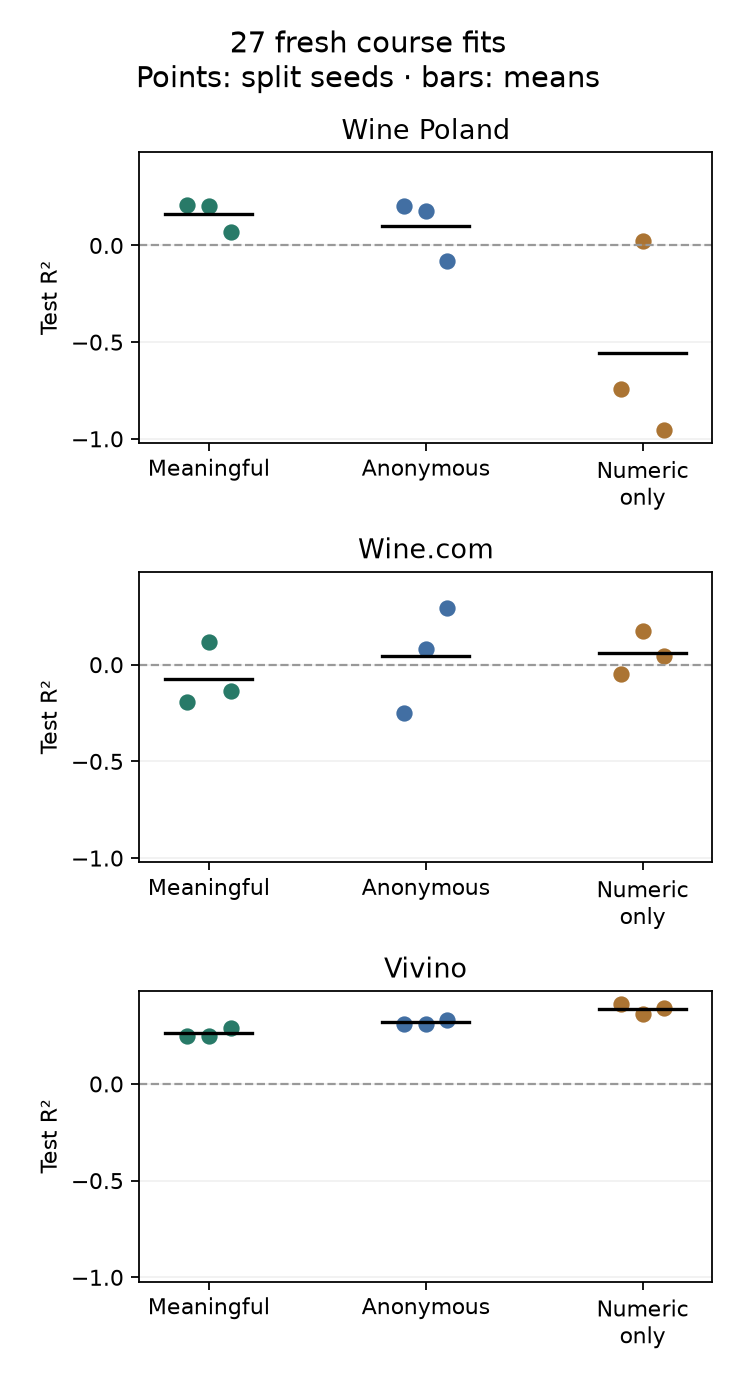

Black bars are means; points are split seeds. These are author reference results, not a claim that a blank student notebook has run.

| Table | Meaningful | Anonymous | Numeric-only |
|---|---:|---:|---:|
| wine_pl | 0.162 ± 0.079 | 0.101 ± 0.160 | -0.557 ± 0.515 |
| wine_dot_com_prices | -0.072 ± 0.167 | 0.043 ± 0.273 | 0.058 ± 0.113 |
| wine_vivino_price | 0.262 ± 0.024 | 0.318 ± 0.012 | 0.388 ± 0.027 |

Mean test R² ± sample SD across three paired split seeds. Full data: the portable course-audit.json and freshly generated b07-report.json.


Meaningful names help only wine_pl by mean R². Wine.com anonymous-name effects are negative on two splits and strongly positive on one. Numeric-only also has mixed effects. Three related domains, one arbitrary pseudonym scheme and a frozen probe do not establish general semantic-model superiority.

## EXIT · Defend the causal claim
1. Explain name removal versus text removal and why numeric-only cannot isolate semantic quality.
2. Show the exact(table,seed) paired effects, including disagreeing split signs.
3. Draw all-class target tokens without feeding the unknown query answer.
4. Contrast ConTextTab context adaptation with TabSTAR LoRA updates.
5. Propose two falsifiers and identify required source evidence before original Table 2 dispatch.

Your written defense is not auto-graded. Ask the agent for feedback; author checks do not establish learner mastery. Retrieve after 1/7/30 days following completion.

In [ ]:
submission={'status':'PENDING_WRITTEN_DEFENSE','defense':''}
Path('b07-submission.json').write_text(json.dumps(submission,indent=2))
print(submission['status'])

## NEXT STEP · Original published target, not a larger course run
B07-CONTEXTTAB-BAGGING targets originalv1 Table 2 binning base versus without bagging across the complete CARTE subset. Missing original binning checkpoint/configuration, full split identities and evaluator mean INCOMPLETE_SOURCE_PROTOCOL. The tested command below refuses dispatch. It is a source preflight, not a complete runnable paper trainer/evaluator. No Modal operator is supplied because dispatch cannot resolve missing scientific inputs. Full pretraining and original benchmark NOT_RUN.

Primary sources: [CARTE](https://arxiv.org/html/2402.16785v2#S3), [ConTextTab](https://arxiv.org/html/2506.10707v1#S5.T2), [TabSTAR](https://arxiv.org/html/2505.18125v2#S3), [SAP model card](https://huggingface.co/SAP/sap-rpt-1-oss). Archived source files and licenses are in the portable source archive. Course does not implement/train TabSTAR or ConTextTab from scratch; it implements and executes the selected CARTE probe.


In [ ]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    subprocess.run([sys.executable,str(lab/'_reproduce_b07.py'),'--run'],check=True)
else:
    print('Original paper NOT_RUN: source gate',source['status'])